In [1]:
import optuna.exceptions
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import time
import torchvision.models as models
from matplotlib import pyplot as plt

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

## Load Data

In [8]:
image_transforms = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

In [9]:
dataset_path = './dataset'

dataset = datasets.ImageFolder(root=dataset_path, transform=image_transforms)
len(dataset)

2300

In [4]:
dataset.classes

['F_Breakage', 'F_Crushed', 'F_Normal', 'R_Breakage', 'R_Crushed', 'R_Normal']

In [5]:
num_classes = len(dataset.classes)
num_classes

6

In [10]:
train_size = int(0.75*len(dataset))
val_size = len(dataset) - train_size

train_size, val_size

(1725, 575)

In [11]:
from torch.utils.data import random_split

train_dataset, val_dataset = random_split(dataset, [train_size, val_size])

In [35]:
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=True, pin_memory=True)

In [36]:
for images, labels in train_loader:
    images = images.to(device)
    labels = labels.to(device)
    break

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.0494049..2.5179958].


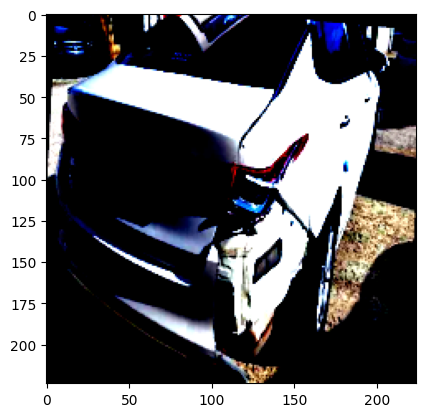

In [37]:
plt.imshow(images[0].cpu().permute(1,2,0))
plt.show()

## Train Model 1: CNN

In [38]:
class CarClassifierCNN(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.network = nn.Sequential(
            nn.Conv2d(in_channels=3, out_channels=16, kernel_size=(3,3), stride=1, padding=1), # input: (16, 224, 224)
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2, padding=0), # output: (16, 112, 112)

            nn.Conv2d(16, 32, (3,3), 1, 1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2, padding=0), # output: (32, 56, 56)

            nn.Conv2d(32, 64, (3,3), 1, 1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2, padding=0), # output: (64, 28, 28)

            nn.Flatten(),
            nn.Linear(64*28*28, 512),
            nn.ReLU(),
            nn.Linear(512, num_classes)
        )

    def forward(self, x):
        return self.network(x)

In [39]:
model = CarClassifierCNN(num_classes=num_classes).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [40]:
images.size(0)

32

In [77]:
def train_model(model, criterion, optimizer, train_loader, epochs=5):
    start = time.time()
    # Model Training:

    for epoch in range(epochs):
        model.train()
        scaler = torch.amp.GradScaler('cuda')
        running_loss = 0.0

        for batch_num, (images, labels) in enumerate(train_loader):
            images = images.to(device)
            labels = labels.to(device)
            # Zero the parameter gradients
            optimizer.zero_grad()
            # Forward pass
            with torch.amp.autocast('cuda'):
                outputs = model(images)
                loss = criterion(outputs, labels)
            # Backward pass
            scaler.scale(loss).backward()
            # Update the weights
            scaler.step(optimizer)
            scaler.update()

            if (batch_num+1) % 10 == 0:
                print(f"Batch: {batch_num+1}, Epoch: {epoch+1}, Loss: {loss.item():.2f}")

            running_loss += loss.item() * images.size(0)

        epoch_loss = running_loss/len(train_loader.dataset)
        print(f"Epoch [{epoch+1}/{epochs}], Loss: {epoch_loss:.4f}")

    # Model Evaluation:

        model.eval()
        total = 0.0
        correct = 0.0
        all_labels = []
        all_predictions = []
        with torch.no_grad():

            for images, labels in val_loader:
                images = images.to(device)
                labels = labels.to(device)
                outputs = model(images)
                _, predicted = torch.max(outputs, 1)
                total += labels.size(0)
                correct += (predicted == labels).sum().item()
                all_labels.extend(labels.cpu().numpy())
                all_predictions.extend(predicted.cpu().numpy())

            print(f"Validation Accuracy: {100 * correct / total:.2f}%")
    end = time.time()
    print(f'Execution time: {end - start} seconds')

    return all_labels, all_predictions

In [43]:
all_labels, all_predictions = train_model(model, criterion, optimizer, train_loader, epochs=5)

Batch: 10, Epoch: 1, Loss: 1.39
Batch: 20, Epoch: 1, Loss: 1.36
Batch: 30, Epoch: 1, Loss: 1.25
Batch: 40, Epoch: 1, Loss: 1.14
Batch: 50, Epoch: 1, Loss: 1.17
Epoch [1/5], Loss: 1.2869
Validation Accuracy: 52.70%
Batch: 10, Epoch: 2, Loss: 1.19
Batch: 20, Epoch: 2, Loss: 1.13
Batch: 30, Epoch: 2, Loss: 1.13
Batch: 40, Epoch: 2, Loss: 1.23
Batch: 50, Epoch: 2, Loss: 0.81
Epoch [2/5], Loss: 1.0844
Validation Accuracy: 53.04%
Batch: 10, Epoch: 3, Loss: 1.05
Batch: 20, Epoch: 3, Loss: 0.92
Batch: 30, Epoch: 3, Loss: 1.00
Batch: 40, Epoch: 3, Loss: 0.70
Batch: 50, Epoch: 3, Loss: 0.80
Epoch [3/5], Loss: 0.9767
Validation Accuracy: 54.09%
Batch: 10, Epoch: 4, Loss: 0.93
Batch: 20, Epoch: 4, Loss: 0.70
Batch: 30, Epoch: 4, Loss: 0.86
Batch: 40, Epoch: 4, Loss: 0.98
Batch: 50, Epoch: 4, Loss: 0.92
Epoch [4/5], Loss: 0.8946
Validation Accuracy: 50.26%
Batch: 10, Epoch: 5, Loss: 0.70
Batch: 20, Epoch: 5, Loss: 0.94
Batch: 30, Epoch: 5, Loss: 0.85
Batch: 40, Epoch: 5, Loss: 1.05
Batch: 50, Epoch

## Train Model 2: CNN with Regularization

In [44]:
class CarClassifierCNN(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.network = nn.Sequential(
            nn.Conv2d(in_channels=3, out_channels=16, kernel_size=(3,3), stride=1, padding=1), # input: (16, 224, 224)
            nn.BatchNorm2d(16),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2, padding=0), # output: (16, 112, 112)

            nn.Conv2d(16, 32, (3,3), 1, 1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2, padding=0), # output: (32, 56, 56)

            nn.Conv2d(32, 64, (3,3), 1, 1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2, padding=0), # output: (64, 28, 28)

            nn.Flatten(),
            nn.Linear(64*28*28, 512),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(512, num_classes)
        )

    def forward(self, x):
        return self.network(x)

In [45]:
model = CarClassifierCNN(num_classes=num_classes).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-4)

In [46]:
all_labels, all_predictions = train_model(model, criterion, optimizer, train_loader, epochs=10)

Batch: 10, Epoch: 1, Loss: 40.79
Batch: 20, Epoch: 1, Loss: 15.44
Batch: 30, Epoch: 1, Loss: 6.51
Batch: 40, Epoch: 1, Loss: 1.64
Batch: 50, Epoch: 1, Loss: 1.73
Epoch [1/10], Loss: 10.9250
Validation Accuracy: 36.87%
Batch: 10, Epoch: 2, Loss: 1.59
Batch: 20, Epoch: 2, Loss: 1.39
Batch: 30, Epoch: 2, Loss: 1.37
Batch: 40, Epoch: 2, Loss: 1.43
Batch: 50, Epoch: 2, Loss: 1.45
Epoch [2/10], Loss: 1.4990
Validation Accuracy: 40.87%
Batch: 10, Epoch: 3, Loss: 1.49
Batch: 20, Epoch: 3, Loss: 1.44
Batch: 30, Epoch: 3, Loss: 1.48
Batch: 40, Epoch: 3, Loss: 1.41
Batch: 50, Epoch: 3, Loss: 1.50
Epoch [3/10], Loss: 1.4160
Validation Accuracy: 48.17%
Batch: 10, Epoch: 4, Loss: 1.47
Batch: 20, Epoch: 4, Loss: 1.30
Batch: 30, Epoch: 4, Loss: 1.12
Batch: 40, Epoch: 4, Loss: 1.22
Batch: 50, Epoch: 4, Loss: 1.31
Epoch [4/10], Loss: 1.3359
Validation Accuracy: 48.17%
Batch: 10, Epoch: 5, Loss: 1.26
Batch: 20, Epoch: 5, Loss: 1.18
Batch: 30, Epoch: 5, Loss: 1.69
Batch: 40, Epoch: 5, Loss: 1.18
Batch: 50

## Train Model 3: Transfer Learning with EfficientNet

In [49]:
class CarClassifierEfficientNet(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.model = models.efficientnet_b0(weights='DEFAULT')

        for param in self.model.parameters():
            param.requires_grad = False

        in_features = self.model.classifier[1].in_features

        self.model.classifier = nn.Sequential(
            nn.Dropout(0.5),
            nn.Linear(in_features, num_classes)
        )

    def forward(self, x):
        return self.model(x)

In [50]:
model = CarClassifierEfficientNet(num_classes=num_classes).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=0.001)

all_labels, all_predictions = train_model(model, criterion, optimizer, train_loader, epochs=10)

Batch: 10, Epoch: 1, Loss: 1.55
Batch: 20, Epoch: 1, Loss: 1.41
Batch: 30, Epoch: 1, Loss: 1.35
Batch: 40, Epoch: 1, Loss: 1.25
Batch: 50, Epoch: 1, Loss: 1.23
Epoch [1/10], Loss: 1.4611
Validation Accuracy: 57.91%
Batch: 10, Epoch: 2, Loss: 1.17
Batch: 20, Epoch: 2, Loss: 1.06
Batch: 30, Epoch: 2, Loss: 1.07
Batch: 40, Epoch: 2, Loss: 1.45
Batch: 50, Epoch: 2, Loss: 1.10
Epoch [2/10], Loss: 1.1355
Validation Accuracy: 60.00%
Batch: 10, Epoch: 3, Loss: 0.94
Batch: 20, Epoch: 3, Loss: 0.94
Batch: 30, Epoch: 3, Loss: 1.04
Batch: 40, Epoch: 3, Loss: 1.10
Batch: 50, Epoch: 3, Loss: 1.02
Epoch [3/10], Loss: 0.9989
Validation Accuracy: 61.74%
Batch: 10, Epoch: 4, Loss: 0.94
Batch: 20, Epoch: 4, Loss: 0.94
Batch: 30, Epoch: 4, Loss: 0.91
Batch: 40, Epoch: 4, Loss: 0.99
Batch: 50, Epoch: 4, Loss: 0.93
Epoch [4/10], Loss: 0.9431
Validation Accuracy: 62.43%
Batch: 10, Epoch: 5, Loss: 1.04
Batch: 20, Epoch: 5, Loss: 1.02
Batch: 30, Epoch: 5, Loss: 1.06
Batch: 40, Epoch: 5, Loss: 0.73
Batch: 50, E

## Model 4: Transfer Learning with ResNet (with hyperparameters updated from Optuna study)

In [74]:
class CarClassifierResNet(nn.Module):
    def __init__(self, num_classes, dropout_rate=0.5):
        super().__init__()
        self.model = models.resnet50(weights='DEFAULT')
        # Freeze all layers except the final fully connected layer
        for param in self.model.parameters():
            param.requires_grad = False
        # Unfreeze layer 4 and fc layers
        for param in self.model.layer4.parameters():
            param.requires_grad = True
        # Replace the final fully connected layer
        self.model.fc = nn.Sequential(
            nn.Dropout(dropout_rate),
            nn.Linear(self.model.fc.in_features, num_classes)
        )

    def forward(self, x):
        return self.model(x)

In [79]:
model = CarClassifierResNet(num_classes=num_classes, dropout_rate=0.44).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=0.0021)

labels, predictions = train_model(model, criterion, optimizer, train_loader, epochs=6)

Batch: 10, Epoch: 1, Loss: 0.73
Batch: 20, Epoch: 1, Loss: 0.64
Batch: 30, Epoch: 1, Loss: 0.54
Batch: 40, Epoch: 1, Loss: 0.64
Batch: 50, Epoch: 1, Loss: 0.63
Epoch [1/6], Loss: 0.8771
Validation Accuracy: 74.78%
Batch: 10, Epoch: 2, Loss: 0.29
Batch: 20, Epoch: 2, Loss: 0.39
Batch: 30, Epoch: 2, Loss: 0.40
Batch: 40, Epoch: 2, Loss: 0.69
Batch: 50, Epoch: 2, Loss: 0.54
Epoch [2/6], Loss: 0.4914
Validation Accuracy: 76.52%
Batch: 10, Epoch: 3, Loss: 0.29
Batch: 20, Epoch: 3, Loss: 0.22
Batch: 30, Epoch: 3, Loss: 0.35
Batch: 40, Epoch: 3, Loss: 0.56
Batch: 50, Epoch: 3, Loss: 0.16
Epoch [3/6], Loss: 0.3005
Validation Accuracy: 76.87%
Batch: 10, Epoch: 4, Loss: 0.36
Batch: 20, Epoch: 4, Loss: 0.32
Batch: 30, Epoch: 4, Loss: 0.33
Batch: 40, Epoch: 4, Loss: 0.41
Batch: 50, Epoch: 4, Loss: 0.32
Epoch [4/6], Loss: 0.2995
Validation Accuracy: 71.65%
Batch: 10, Epoch: 5, Loss: 0.41
Batch: 20, Epoch: 5, Loss: 0.26
Batch: 30, Epoch: 5, Loss: 0.19
Batch: 40, Epoch: 5, Loss: 0.13
Batch: 50, Epoch

## Model Evaluation with Classification Report and Confusion Matrix

In [80]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from matplotlib import pyplot as plt

report = classification_report(labels, predictions)
print(report)

              precision    recall  f1-score   support

           0       0.77      0.93      0.84       127
           1       0.76      0.66      0.71       102
           2       0.95      0.85      0.90       129
           3       0.64      0.86      0.74        74
           4       0.74      0.57      0.64        76
           5       0.85      0.75      0.79        67

    accuracy                           0.79       575
   macro avg       0.78      0.77      0.77       575
weighted avg       0.80      0.79      0.78       575



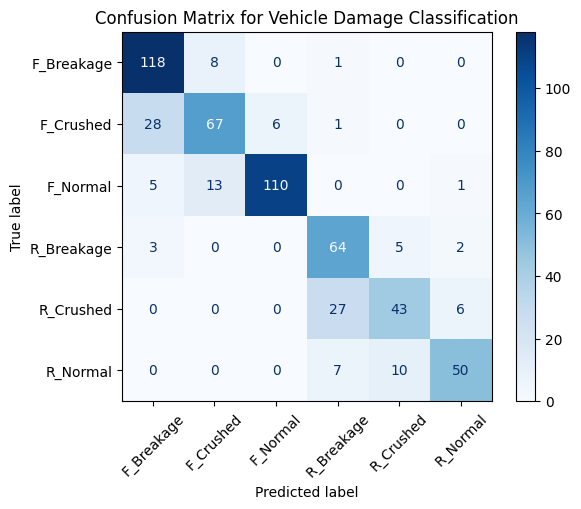

In [82]:
import numpy as np

class_names = dataset.classes

conf_matrix = confusion_matrix(labels, predictions, labels=np.arange(num_classes))
disp = ConfusionMatrixDisplay(confusion_matrix=conf_matrix, display_labels=class_names)
disp.plot(cmap=plt.cm.Blues, xticks_rotation=45)
plt.title("Confusion Matrix for Vehicle Damage Classification")
plt.show()

In [83]:
torch.save(model.state_dict(), 'saved_model.pth')